In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from tqdm import tqdm
import time
from scipy.spatial.distance import cdist
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 

import rmm
import cupy
import cudf
import cupy as cp
import cvxpy as cpv
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
%%time
fpath = "../../resources/gene_names.tsv.gz"
gdf = pd.read_csv(fpath, sep='\t', low_memory=False)
print(f"{gdf.shape=}")

protein_coding = gdf[gdf['Gene type'] == 'protein_coding']['Gene name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(73466, 8)
N protein coding: protein_coding.shape=(18149,)
CPU times: user 129 ms, sys: 23 ms, total: 152 ms
Wall time: 152 ms


In [3]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/single_cell_atlas.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 1.59 s, sys: 14.5 s, total: 16 s
Wall time: 55.6 s


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 521348 × 17601
    obs: 'annotation', 'cell_type', 'tissue', 'development_stage', 'basename', 'dataset_id', 'data_key', 'data_source', 'celltype', 'source'

In [4]:
print(adata.obs['data_key'].value_counts().to_string())

data_key
Ng 2024       250000
Reference     250000
This Study     21062
Gomes 2018       286


# Sampling

In [5]:
# n_cells = 250000 # about half
# adata = sc.pp.sample(adata, n=n_cells, replace=False, copy=True)

In [6]:
print(adata.obs['data_key'].value_counts().to_string())

data_key
Ng 2024       250000
Reference     250000
This Study     21062
Gomes 2018       286


In [7]:
print(adata.obs['source'].value_counts().to_string())

source
hsc            8310
fib            7294
bone_marrow    5458


# data source variable

In [8]:
print(f"{adata.obs.shape=}")

adata.obs["batch_key"] = adata.obs["dataset_id"].astype(str)
adata.obs["batch_key"] = np.where(adata.obs["batch_key"] == 'nan', adata.obs["data_key"].astype(str), adata.obs["batch_key"])
adata.obs["batch_key"] = np.where(adata.obs["data_key"] == 'This Study', adata.obs["source"].astype(str), adata.obs["batch_key"])

print(adata.obs[['batch_key', 'data_key', 'data_source']].head().to_string())

print()

print(adata.obs["batch_key"].value_counts(dropna=False).head(25))

adata.obs.shape=(521348, 10)
                                    batch_key   data_key data_source
1257969  9f222629-9e39-47d0-b83f-e08d610c7479  Reference           0
609700   3c361813-5d5e-4868-bfe5-e7591e7b5381  Reference           0
637545   842c6f5d-4a94-4eef-8510-8c792d1124bc  Reference           0
543374   842c6f5d-4a94-4eef-8510-8c792d1124bc  Reference           0
756827   842c6f5d-4a94-4eef-8510-8c792d1124bc  Reference           0

batch_key
Ng 2024                                 250000
842c6f5d-4a94-4eef-8510-8c792d1124bc     23532
0ba636a1-4754-4786-a8be-7ab3cf760fd6     20070
fd072bc3-2dfb-46f8-b4e3-467cb3223182     18940
d4e69e01-3ba2-4d6b-a15d-e7048f78f22e     18485
2adb1f8a-a6b1-4909-8ee8-484814e2d4bf     15514
55003f67-c494-46f1-83fb-902745646379     10948
9968be68-ab65-4a38-9e1a-c9b6abece194     10362
535e9336-2d8d-43c3-944d-bcbebe20df8a      9383
18e2a8c5-33f7-455e-a58a-b2ba6921db27      9233
f7c1c579-2dc0-47e2-ba19-8165c5a0e353      8340
471647b3-04fe-4c76-8372-3264f

In [9]:
threshold = 100 # fewer than 10 cells from a given source are dropped

# Count how many times each batch appears
batch_counts = adata.obs["batch_key"].value_counts()

# Identify non-unique batch keys
non_unique_batches = batch_counts[batch_counts > threshold].index

# Subset the AnnData to only those with non-unique batch keys
adata = adata[adata.obs["batch_key"].isin(non_unique_batches)].copy()

print(f"{adata.shape=}")
adata

adata.shape=(518489, 17601)


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 518489 × 17601
    obs: 'annotation', 'cell_type', 'tissue', 'development_stage', 'basename', 'dataset_id', 'data_key', 'data_source', 'celltype', 'source', 'batch_key'

# Preprocessing

In [10]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs.head()

CPU times: user 1min 20s, sys: 41.4 s, total: 2min 1s
Wall time: 2min 2s


,annotation,cell_type,tissue,development_stage,basename,dataset_id,data_key,data_source,celltype,source,batch_key,S_score,G2M_score,phase
1257969,alveolar type 2 fibroblast cell,alveolar type 2 fibroblast cell,lung parenchyma,52-year-old human stage,fibroblasts,9f222629-9e39-47d0-b83f-e08d610c7479,Reference,0,NaN,NaN,9f222629-9e39-47d0-b83f-e08d610c7479,-1.066978,-1.573436,G1
609700,endothelial cell,endothelial cell,dorsolateral prefrontal cortex,36-year-old human stage,endothelial_cells,3c361813-5d5e-4868-bfe5-e7591e7b5381,Reference,0,NaN,NaN,3c361813-5d5e-4868-bfe5-e7591e7b5381,-0.087067,-0.070756,G1
637545,fibroblast,fibroblast,breast,mature stage,fibroblasts,842c6f5d-4a94-4eef-8510-8c792d1124bc,Reference,0,NaN,NaN,842c6f5d-4a94-4eef-8510-8c792d1124bc,-0.471114,-0.662005,G1
543374,vascular associated smooth muscle cell,vascular associated smooth muscle cell,breast,mature stage,mesenchymal_cells,842c6f5d-4a94-4eef-8510-8c792d1124bc,Reference,0,NaN,NaN,842c6f5d-4a94-4eef-8510-8c792d1124bc,-0.184564,-0.162488,G1
756827,fibroblast,fibroblast,breast,mature stage,fibroblasts,842c6f5d-4a94-4eef-8510-8c792d1124bc,Reference,0,NaN,NaN,842c6f5d-4a94-4eef-8510-8c792d1124bc,-0.301651,-0.391569,G1


In [11]:
%%time
rsc.get.anndata_to_CPU(adata)
X = adata.X

if sp.issparse(X):
    # replace NaNs in the nonzero entries
    X.data = np.nan_to_num(X.data, nan=0)
    adata.X = X
else:
    # dense array
    adata.X = np.nan_to_num(X, nan=0)

adata.X = adata.X.astype(float)
print(f"{adata.X.shape=}")
print(f"{type(adata.X)=}")
print(f"{adata.X.dtype=}")

adata

adata.X.shape=(518489, 17601)
type(adata.X)=<class 'scipy.sparse._csr.csr_matrix'>
adata.X.dtype=dtype('float64')
CPU times: user 19.6 s, sys: 17.9 s, total: 37.6 s
Wall time: 37.7 s


AnnData object with n_obs × n_vars = 518489 × 17601
    obs: 'annotation', 'cell_type', 'tissue', 'development_stage', 'basename', 'dataset_id', 'data_key', 'data_source', 'celltype', 'source', 'batch_key', 'S_score', 'G2M_score', 'phase'

In [12]:
adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
True     17373
False      228


# standard processing

In [13]:
%%time
print("Annotating mitochondrial, ribosomal, and hemoglobin genes...")
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

print("Moving AnnData to CPU for QC metric calculation...")
rsc.get.anndata_to_CPU(adata)

print("Calculating QC metrics (log1p transformed)...")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], 
    inplace=True, log1p=True
)

adata.var.head()

Annotating mitochondrial, ribosomal, and hemoglobin genes...
Moving AnnData to CPU for QC metric calculation...
Calculating QC metrics (log1p transformed)...
CPU times: user 41.9 s, sys: 4 s, total: 45.9 s
Wall time: 26.2 s


,filter_pass,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
A1CF,True,False,False,False,747,0.005614,0.005598,99.855928,2.910751e+03,7.976510
A2M,True,False,False,False,106676,3.939051,1.597173,79.425600,2.042355e+06,14.529615
A2ML1,True,False,False,False,1164,0.003138,0.003133,99.775502,1.626936e+03,7.395068
A3GALT2,True,False,False,False,313,0.000669,0.000669,99.939632,3.470000e+02,5.852202
A4GALT,True,False,False,False,36123,0.143369,0.133979,93.033025,7.433504e+04,11.216351


# Filtering + normalization

In [14]:
%%time

print("Storing raw counts in .layers['raw_counts']...")
adata.layers['raw_counts'] = adata.X.copy()

print("Transferring AnnData back to GPU...")
rsc.get.anndata_to_GPU(adata)

print("Filtering cells with fewer than 500 counts...")
rsc.pp.filter_cells(adata, min_counts=500)

print("Filtering genes with fewer than 10 total counts...")
rsc.pp.filter_genes(adata, min_counts=10)

print("Filtering genes with zero counts across all cells...")
adata = adata[:, (adata.var['total_counts'] > 0)].copy()

min_n_genes = 1000
print(f"Subsetting cells with more than {min_n_genes} genes detected...")
adata = adata[adata.obs['n_genes_by_counts'] > min_n_genes, :].copy()

print("Normalizing total counts to 1e4 per cell...")
rsc.pp.normalize_total(adata, target_sum=1e4)

print("Applying log1p transformation...")
rsc.pp.log1p(adata)

print("Computing highly variable genes...")
rsc.pp.highly_variable_genes(adata)

print("Storing log-normalized data in .layers['log_norm']...")
adata.layers['log_norm'] = adata.X.copy()

print("Preprocessing complete.")
adata

Storing raw counts in .layers['raw_counts']...
Transferring AnnData back to GPU...
Filtering cells with fewer than 500 counts...
filtered out 17898 cells that have less than 500 counts


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Filtering genes with fewer than 10 total counts...
filtered out 227 genes that are detected in less than 10 counts


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Filtering genes with zero counts across all cells...
Subsetting cells with more than 1000 genes detected...
Normalizing total counts to 1e4 per cell...
Applying log1p transformation...
Computing highly variable genes...
Storing log-normalized data in .layers['log_norm']...
Preprocessing complete.
CPU times: user 48.4 s, sys: 55.6 s, total: 1min 44s
Wall time: 1min 45s


AnnData object with n_obs × n_vars = 420366 × 17374
    obs: 'annotation', 'cell_type', 'tissue', 'development_stage', 'basename', 'dataset_id', 'data_key', 'data_source', 'celltype', 'source', 'batch_key', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes'
    var: 'filter_pass', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'raw_counts', 'log_norm'

In [15]:
# break

# Embedding (no batch correction)

[2025-08-04 19:14:21.209] [CUML] [debug] n_neighbors=255
[2025-08-04 19:14:21.210] [CUML] [debug] Calling knn graph run
[2025-08-04 19:14:21.210] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-08-04 19:14:22.766] [CUML] [debug] Done. Calling remove zeros

cluster
A18    52095
A17    51528
A21    46979
A2     30571
A13    28484
A1     23383
A22    22435
A7     21683
A5     19532
A3     18792
A6     16511
A12    14627
A9     14436
A8     13917
A10     8319
A11     7284
A24     7228
A20     5782
A19     5698
A23     4222
A15     2949
A14     1397
A16     1245
A25     1042
A4       227



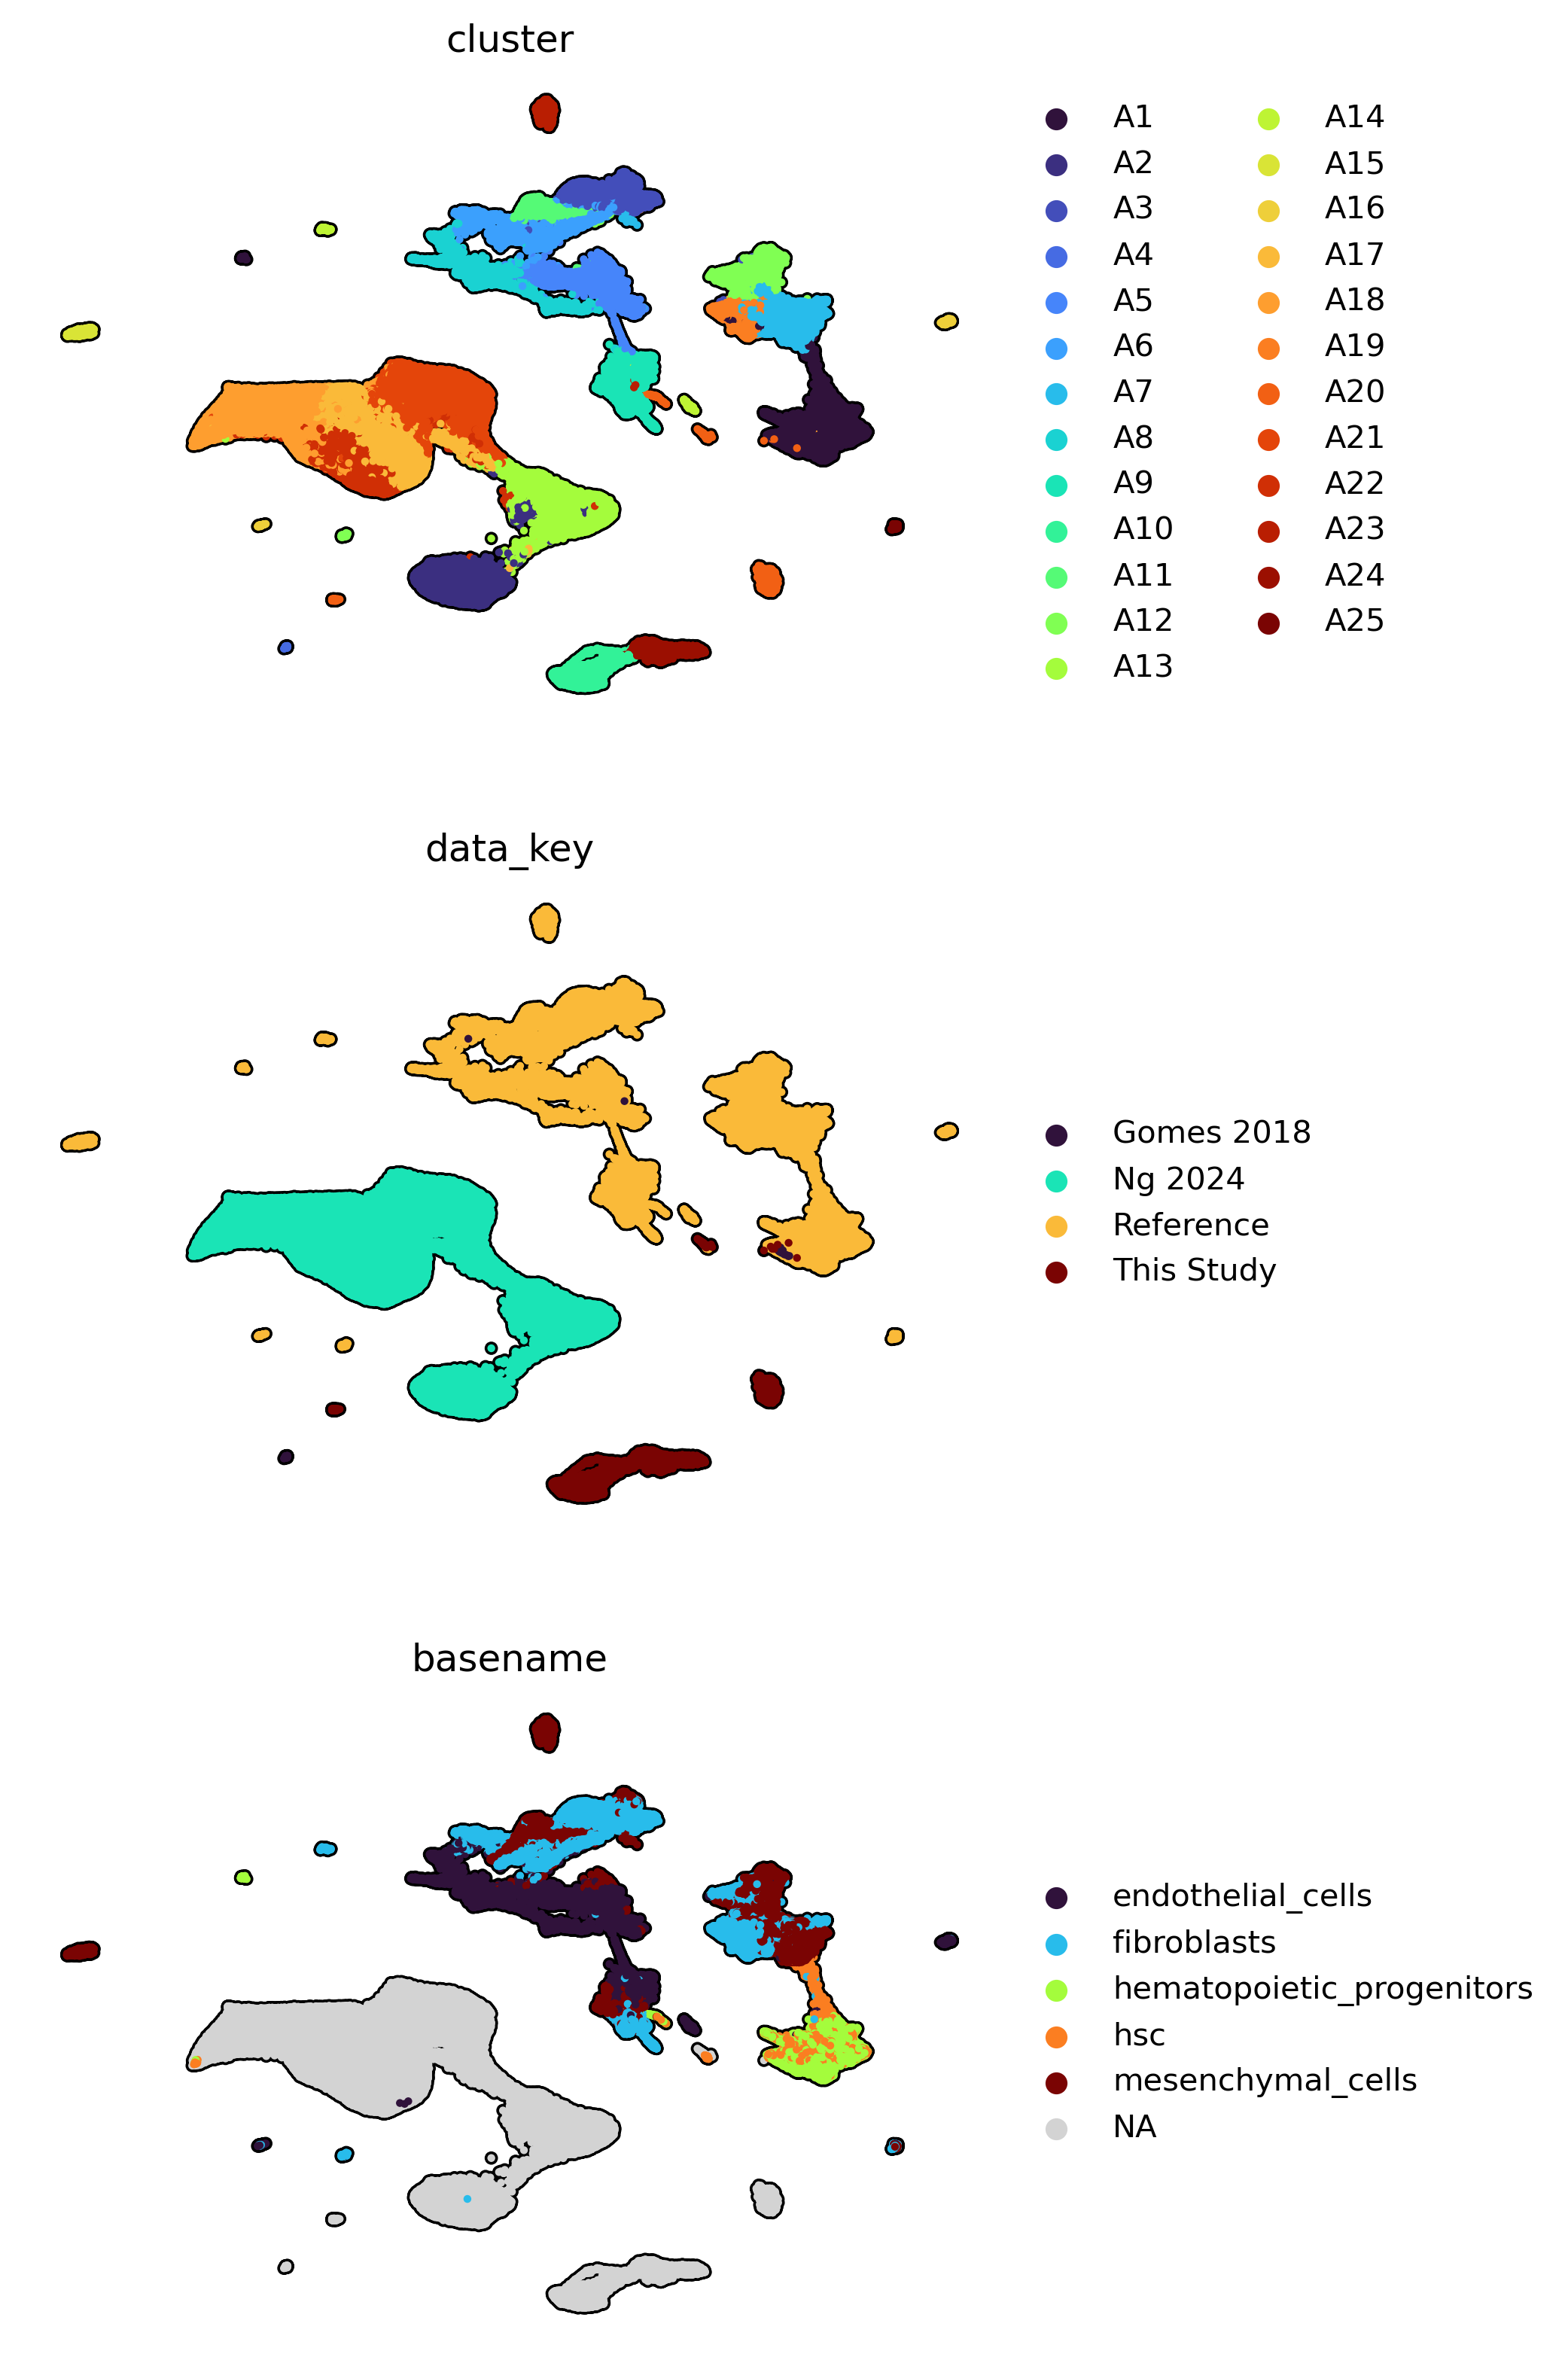

CPU times: user 9min 25s, sys: 45.3 s, total: 10min 11s
Wall time: 10min 14s


In [16]:
%%time

rng = 1729
np.random.seed(rng)

rsc.get.anndata_to_CPU(adata)

rsc.pp.pca(adata, mask_var='filter_pass', random_state=rng)
rsc.pp.neighbors(adata, n_neighbors=255, random_state=rng)
rsc.tl.umap(adata, min_dist=0.4, )
rsc.tl.leiden(adata, resolution=0.38, random_state=rng)

adata.obs['cluster'] = adata.obs['leiden'].apply(lambda x: f"A{int(x) + 1}")
adata.obs['cluster'] = adata.obs['cluster'].astype('str')

print()
print(adata.obs['cluster'].value_counts().to_string())
print()

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['cluster', 'data_key', 'basename'],
    palette='turbo',
    size=25,
    ncols=1,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

# Write Out

In [17]:
%%time
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/single_cell_atlas_processed.h5ad"
adata.write(outpath)
adata

CPU times: user 9.94 s, sys: 22.7 s, total: 32.6 s
Wall time: 1min 46s


AnnData object with n_obs × n_vars = 420366 × 17374
    obs: 'annotation', 'cell_type', 'tissue', 'development_stage', 'basename', 'dataset_id', 'data_key', 'data_source', 'celltype', 'source', 'batch_key', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'cluster'
    var: 'filter_pass', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'cluste

In [18]:
# break

# scvi

In [19]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 3g.40gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-98141577-d909-5297-b01a-7934dd19952d]


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Monitored metric elbo_validation = nan is not finite. Previous best value was 785.543. Signaling Trainer to stop.


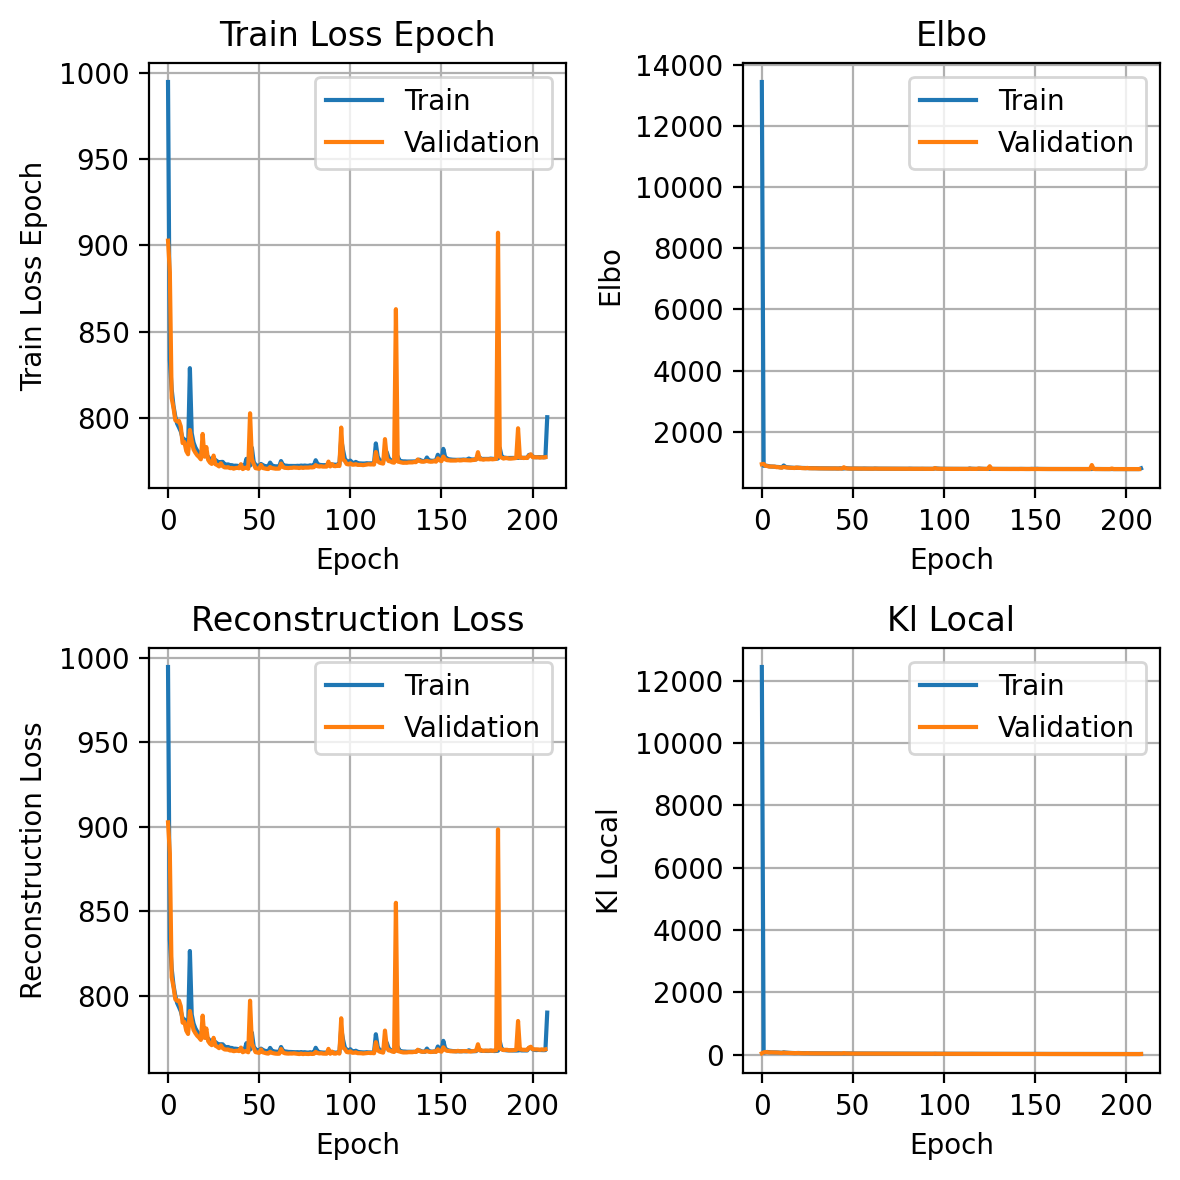

CPU times: user 31min 50s, sys: 2min 8s, total: 33min 59s
Wall time: 34min 10s


In [20]:
%%time
batch_key = "batch_key"

rsc.get.anndata_to_CPU(adata)
bdata = adata.copy()
bdata = bdata[:, bdata.var['filter_pass']].copy()
bdata.X = bdata.layers['raw_counts'].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=3500,
    # batch_key=batch_key
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    batch_key=batch_key,
    continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=24,
    n_layers=2, 
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=500,
    accelerator='gpu',
    early_stopping_patience=30,
    early_stopping=True,
    batch_size=500,
    plan_kwargs={"lr": 1e-3},
)

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# ?model.train

[2025-08-04 19:52:42.971] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization


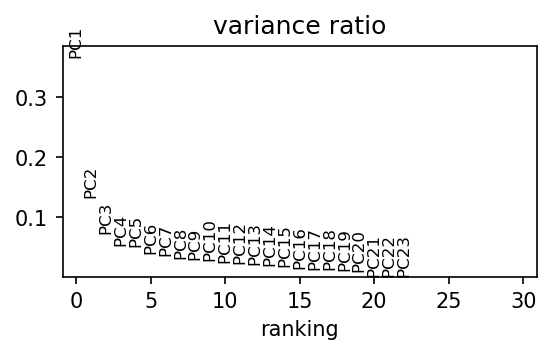

CPU times: user 5.59 s, sys: 371 ms, total: 5.96 s
Wall time: 6.01 s


In [22]:
%%time 

embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)

[2025-08-04 19:52:47.576] [CUML] [debug] n_neighbors=15
[2025-08-04 19:52:47.576] [CUML] [debug] Calling knn graph run
[2025-08-04 19:52:47.576] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-08-04 19:52:47.614] [CUML] [debug] Done. Calling remove zeros

cluster
A4     66267
A3     65681
A10    56415
A6     43390
A14    35984
A1     29828
A13    23684
A7     22585
A8     14835
A5     12208
A15    11919
A11    11492
A2      7036
A9      5093
A17     4604
A12     4391
A16     3517
A18     1437



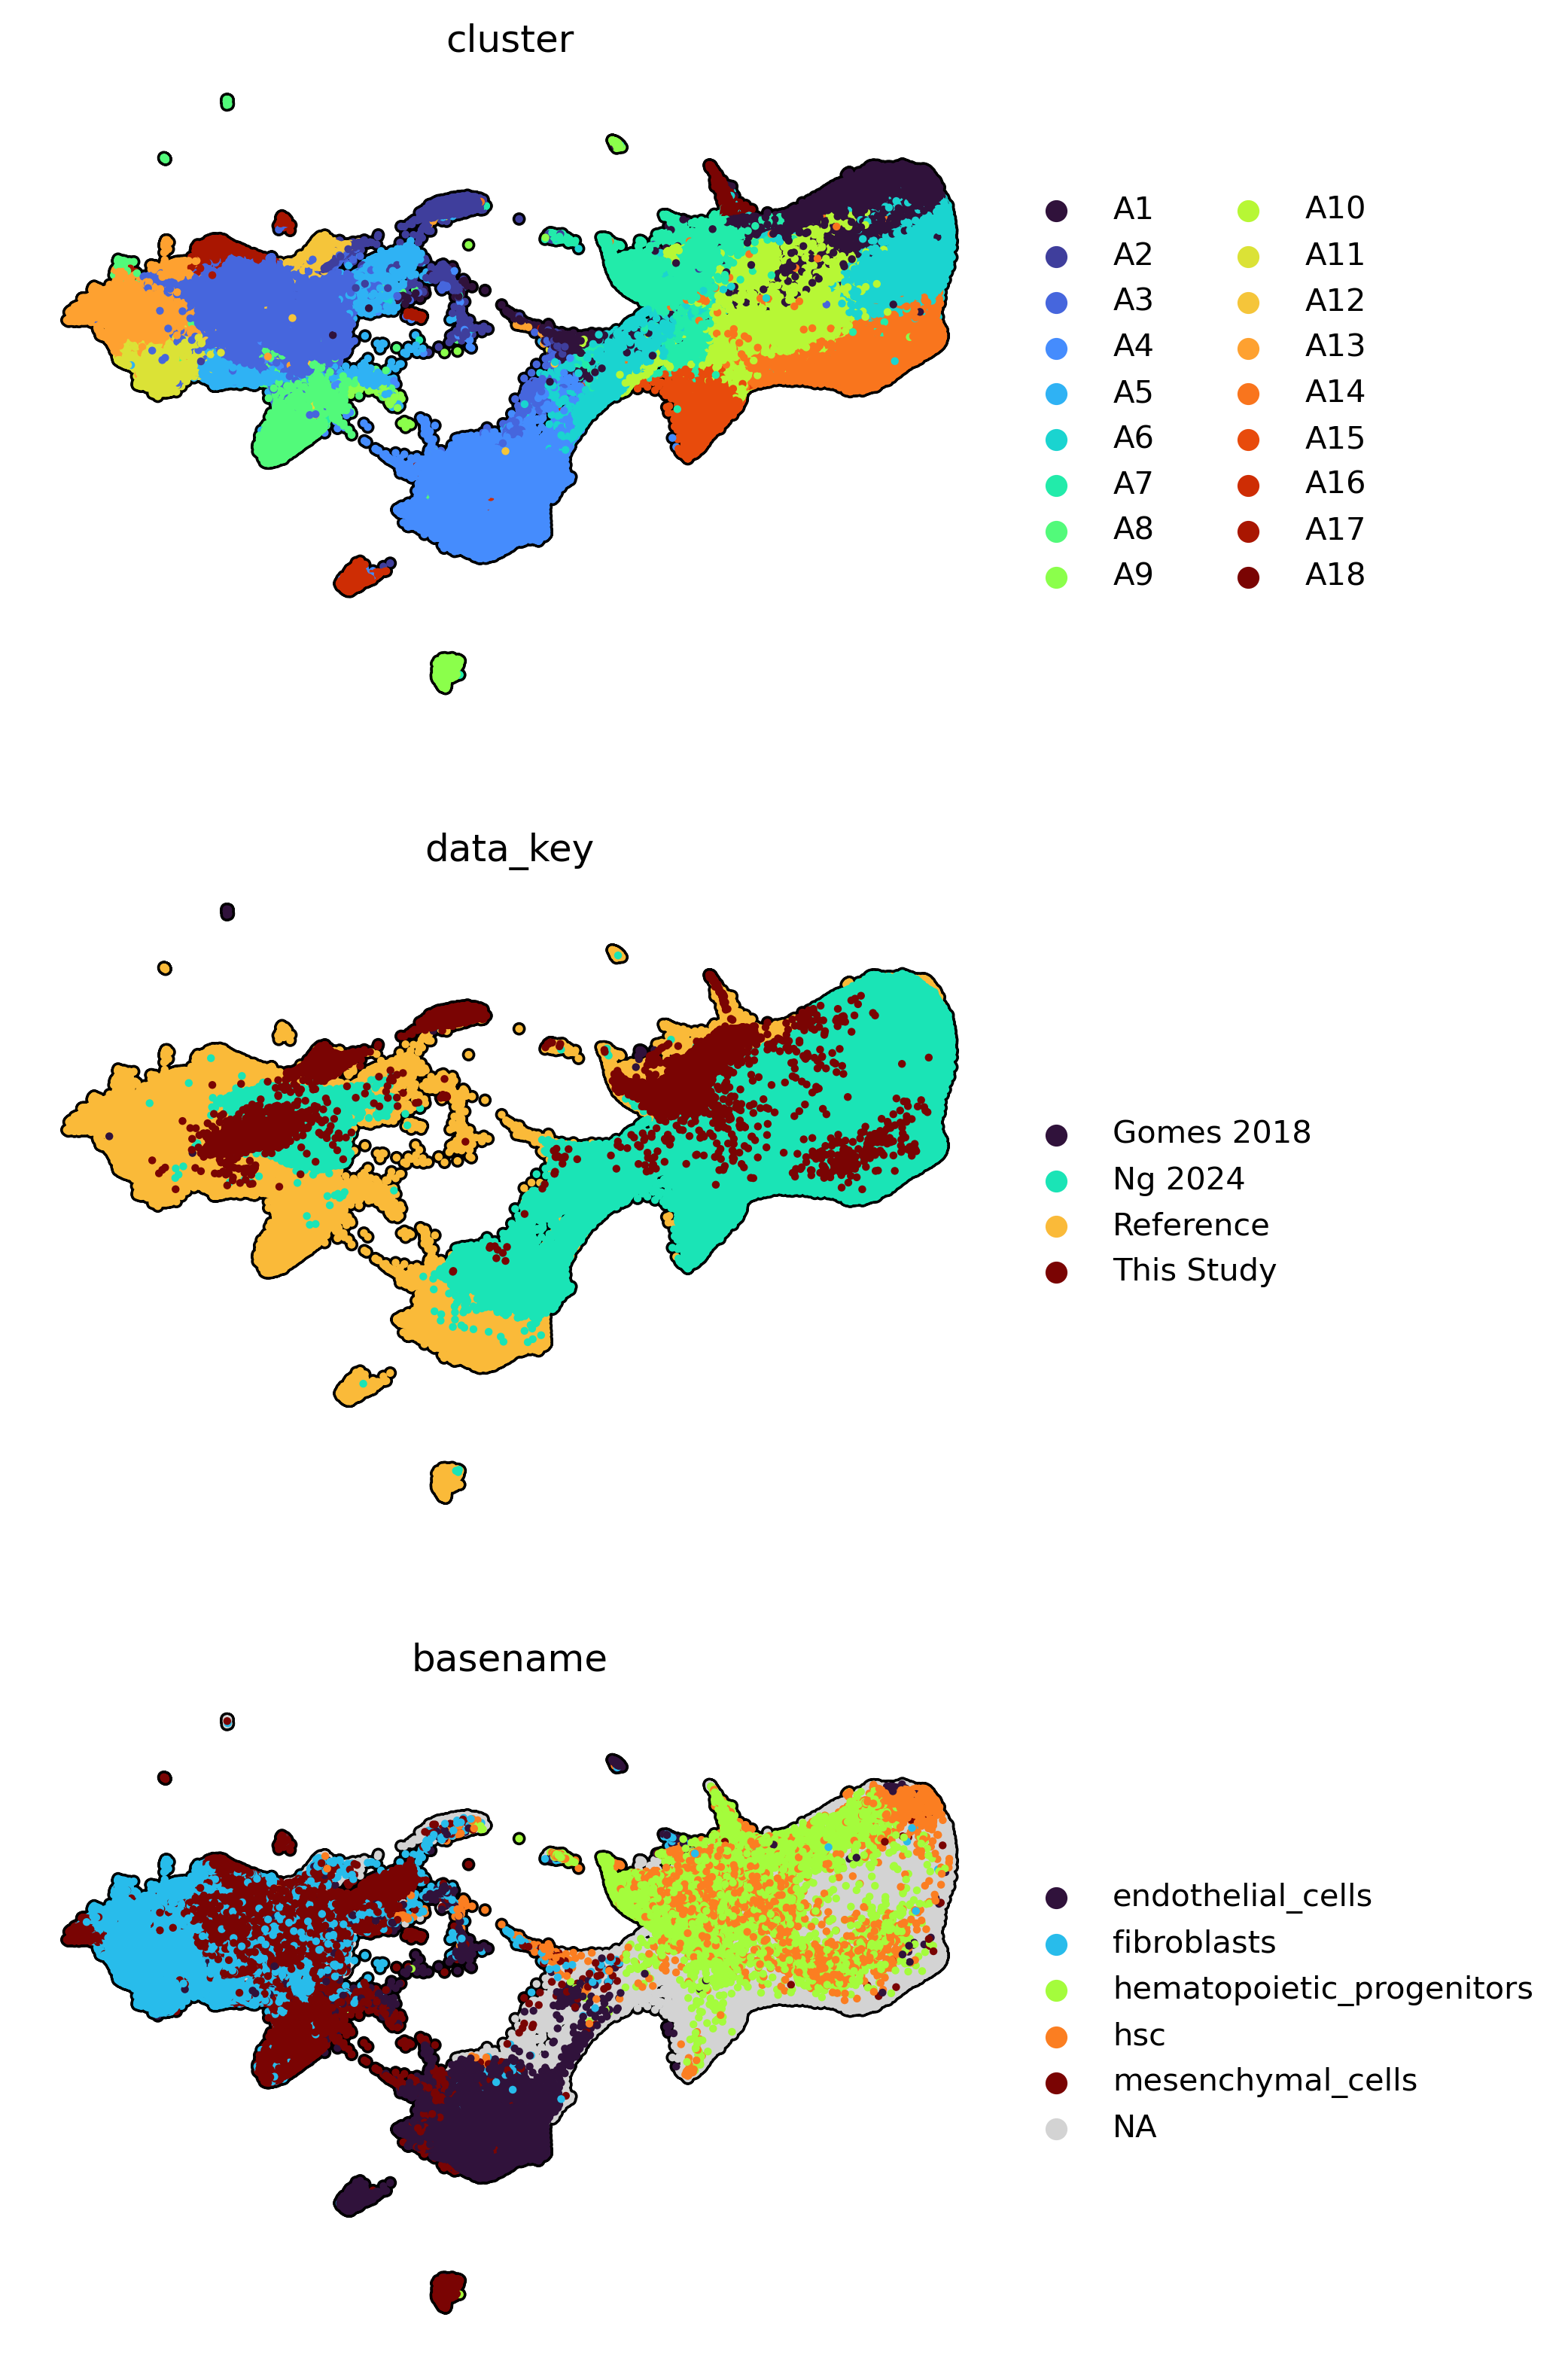

CPU times: user 38 s, sys: 1.62 s, total: 39.6 s
Wall time: 39.7 s


In [23]:
%%time
n_neighbors = 15
n_pcs = 25

rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

rsc.tl.umap(embed, min_dist=0.2, )
rsc.tl.leiden(embed, resolution=0.45, random_state=rng)

embed.obs['cluster'] = embed.obs['leiden'].apply(lambda x: f"A{int(x) + 1}")
embed.obs['cluster'] = embed.obs['cluster'].astype('str')

print()
print(embed.obs['cluster'].value_counts().to_string())
print()

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    embed,
    color=['cluster', 'data_key', 'basename'],
    palette='turbo',
    size=25,
    ncols=1,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [24]:
%%time
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/single_cell_atlas_embedding.h5ad"
embed.write(outpath)
embed

CPU times: user 226 ms, sys: 257 ms, total: 483 ms
Wall time: 2.15 s


AnnData object with n_obs × n_vars = 420366 × 24
    obs: 'annotation', 'cell_type', 'tissue', 'development_stage', 'basename', 'dataset_id', 'data_key', 'data_source', 'celltype', 'source', 'batch_key', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'cluster'
    uns: 'pca', 'neighbors', 'umap', 'leiden', 'cluster_colors', 'data_key_colors', 'basename_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'